In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/selva86/datasets/master/GermanCredit.csv"  #import dati

df = pd.read_csv(url)

print(df.columns)

Index(['status', 'duration', 'credit_history', 'purpose', 'amount', 'savings',
       'employment_duration', 'installment_rate', 'personal_status_sex',
       'other_debtors', 'present_residence', 'property', 'age',
       'other_installment_plans', 'housing', 'number_credits', 'job',
       'people_liable', 'telephone', 'foreign_worker', 'credit_risk'],
      dtype='object')


In [3]:
print(df["credit_risk"].value_counts()) #controllo distribuzione target
#1 buono
#0 cattivo

credit_risk
1    700
0    300
Name: count, dtype: int64


In [4]:
#analisi variabili numeriche
print(df.groupby("credit_risk")["amount"].mean() ) 
print(df.groupby("credit_risk")["duration"].mean())
print(df.groupby("credit_risk")["age"].mean())

credit_risk
0    3938.126667
1    2985.457143
Name: amount, dtype: float64
credit_risk
0    24.860000
1    19.207143
Name: duration, dtype: float64
credit_risk
0    33.963333
1    36.224286
Name: age, dtype: float64


In [5]:
#variabili categoriche
print(pd.crosstab(df["savings"], df["credit_risk"], normalize="index"))
print(pd.crosstab(df["status"], df["credit_risk"], normalize="index"))
print(pd.crosstab(df["housing"], df["credit_risk"], normalize="index"))

credit_risk                        0         1
savings                                       
... < 100 DM                0.359867  0.640133
... >= 1000 DM              0.125000  0.875000
100 <= ... < 500 DM         0.330097  0.669903
500 <= ... < 1000 DM        0.174603  0.825397
unknown/no savings account  0.174863  0.825137
credit_risk                                        0         1
status                                                        
... < 100 DM                                0.492701  0.507299
... >= 200 DM / salary for at least 1 year  0.222222  0.777778
0 <= ... < 200 DM                           0.390335  0.609665
no checking account                         0.116751  0.883249
credit_risk         0         1
housing                        
for free     0.407407  0.592593
own          0.260870  0.739130
rent         0.391061  0.608939


In [20]:
!pip install statsmodels matplotlib seaborn

     ---------------------------------------- 9.6/9.6 MB 8.8 MB/s eta 0:00:00
     ------------------------------------- 233.3/233.3 kB 13.9 MB/s eta 0:00:00



[notice] A new release of pip available: 22.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


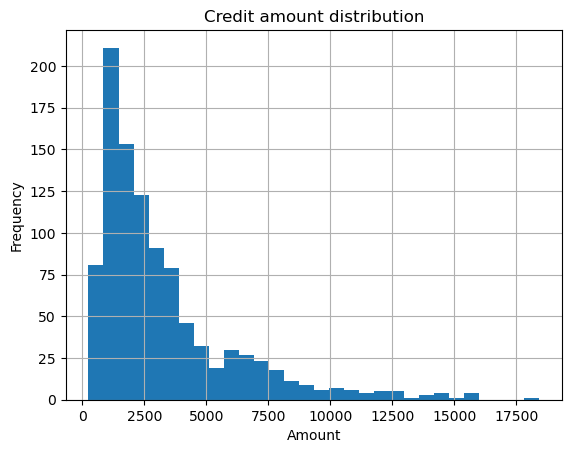

In [2]:
import matplotlib.pyplot as plt
#Istogramma importo prestito
df["amount"].hist(bins=30)

plt.title("Credit amount distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

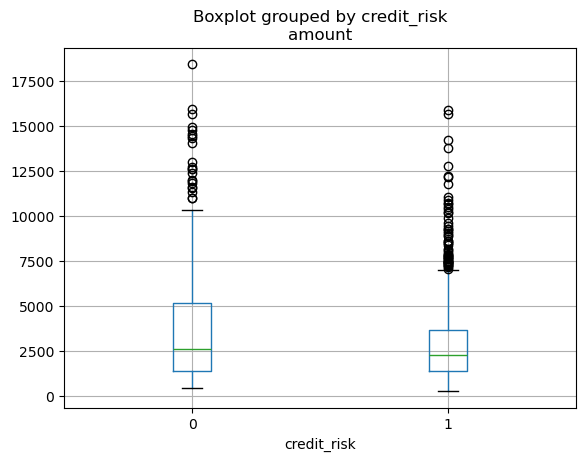

In [7]:
df.boxplot(column="amount", by="credit_risk")
plt.show()

In [8]:
#inizio pulizia
# missing
df_v1 = df.copy()
missing = df_v1.isnull().sum()

missing = missing[missing > 0]

print(missing)
missing_ratio = (df_v1.isnull().mean() * 100).sort_values(ascending=False)

print(missing_ratio) #nessun missing

Series([], dtype: int64)
status                     0.0
property                   0.0
foreign_worker             0.0
telephone                  0.0
people_liable              0.0
job                        0.0
number_credits             0.0
housing                    0.0
other_installment_plans    0.0
age                        0.0
present_residence          0.0
duration                   0.0
other_debtors              0.0
personal_status_sex        0.0
installment_rate           0.0
employment_duration        0.0
savings                    0.0
amount                     0.0
purpose                    0.0
credit_history             0.0
credit_risk                0.0
dtype: float64


In [9]:
#encoding
df_v3 = df_v1.copy()

df_v3 = pd.get_dummies(df_v3, drop_first=True)


In [10]:
X = df_v3.drop("credit_risk", axis=1)

y = df_v3["credit_risk"]

In [ ]:
!pip install scikit-learn

In [11]:
#split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
#modello logistico
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

c:\Users\franc\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [13]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.51      0.47      0.49        60
           1       0.78      0.81      0.79       140

    accuracy                           0.70       200
   macro avg       0.64      0.64      0.64       200
weighted avg       0.70      0.70      0.70       200

ROC-AUC: 0.7553571428571428


In [14]:
#vif
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
X_train_numeric = X_train.astype(float)
vif_data = pd.DataFrame()

vif_data["feature"] = X_train_numeric.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_train_numeric.values, i)
    for i in range(X_train_numeric.shape[1])
]

vif_data["Tolerance"] = 1 / vif_data["VIF"]

print(vif_data.sort_values(by="VIF", ascending=False))
#foreign_worker_yes da eliminare
#anche purpose_domestic_appliances e other_debtors_none


                                              feature        VIF  Tolerance
47                                 foreign_worker_yes  29.445831   0.033961
16                        purpose_domestic appliances  22.394954   0.044653
35                                 other_debtors_none  21.163024   0.047252
41                                        housing_own  19.048247   0.052498
14                                  purpose_car (new)  18.060174   0.055370
4                                                 age  15.847411   0.063102
12  credit_history_existing credits paid back duly...  14.673085   0.068152
20                           purpose_radio/television  14.584340   0.068567
6                                       people_liable  12.631550   0.079167
5                                      number_credits  12.545828   0.079708
2                                    installment_rate  11.507117   0.086903
10  credit_history_critical account/other credits ...  10.443055   0.095757
3           

In [15]:
#eliminiamo e ricalcoliamo
X_train_v2 = X_train.drop(columns=["foreign_worker_yes","purpose_domestic appliances","other_debtors_none"])
X_test_v2 = X_test.drop(columns=["foreign_worker_yes","purpose_domestic appliances","other_debtors_none"])

In [16]:
#ricalcolo modello e vif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

model = LogisticRegression(max_iter=1000)

model.fit(X_train_v2, y_train)
y_pred = model.predict(X_test_v2)

y_prob = model.predict_proba(X_test_v2)[:,1]

print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.53      0.48      0.50        60
           1       0.79      0.81      0.80       140

    accuracy                           0.71       200
   macro avg       0.66      0.65      0.65       200
weighted avg       0.71      0.71      0.71       200

ROC-AUC: 0.7572619047619047


c:\Users\franc\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
X_train_numeric = X_train_v2.astype(float)
vif_data = pd.DataFrame()

vif_data["feature"] = X_train_numeric.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_train_numeric.values, i)
    for i in range(X_train_numeric.shape[1])
]

vif_data["Tolerance"] = 1 / vif_data["VIF"]

print(vif_data.sort_values(by="VIF", ascending=False))

                                              feature        VIF  Tolerance
39                                        housing_own  16.135293   0.061976
4                                                 age  15.232059   0.065651
12  credit_history_existing credits paid back duly...  13.164111   0.075964
5                                      number_credits  12.272103   0.081486
6                                       people_liable  11.761384   0.085024
2                                    installment_rate  10.825743   0.092372
10  credit_history_critical account/other credits ...   9.924508   0.100761
3                                   present_residence   9.879752   0.101217
0                                            duration   8.129207   0.123013
37                       other_installment_plans_none   7.857590   0.127265
41                      job_skilled employee/official   7.189373   0.139094
1                                              amount   5.941323   0.168313
40          

In [18]:
#outlier

df_v4 = df_v3.copy()
num_cols = ["amount", "duration", "age"]

for col in num_cols:
    
    Q1 = df_v4[col].quantile(0.25)
    Q3 = df_v4[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df_v4 = df_v4[
        (df_v4[col] >= lower) &
        (df_v4[col] <= upper)
    ]


In [20]:
removed_rows = len(df_v3) - len(df_v4)

print("Rows removed as outliers:", removed_rows)
removed_pct = (removed_rows / len(df_v3)) * 100

print(f"Percentage removed: {removed_pct:.2f}%")

outliers_removed = df_v3.loc[~df_v3.index.isin(df_v4.index)]

print(outliers_removed.head())

Rows removed as outliers: 138
Percentage removed: 13.80%
    duration  amount  installment_rate  present_residence  age  \
0          6    1169                 4                  4   67   
1         48    5951                 2                  2   22   
5         36    9055                 2                  4   35   
11        48    4308                 3                  4   24   
17        30    8072                 2                  3   25   

    number_credits  people_liable  credit_risk  \
0                2              1            1   
1                1              1            0   
5                1              2            1   
11               1              1            0   
17               3              1            1   

    status_... >= 200 DM / salary for at least 1 year  \
0                                               False   
1                                               False   
5                                               False   
11               

In [21]:
#modello dopo outlier
X = df_v4.drop("credit_risk", axis=1)

y = df_v4["credit_risk"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)



c:\Users\franc\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [22]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
#auc migliora da 0.75 a 0.80

              precision    recall  f1-score   support

           0       0.69      0.39      0.50        46
           1       0.81      0.94      0.87       127

    accuracy                           0.79       173
   macro avg       0.75      0.66      0.68       173
weighted avg       0.78      0.79      0.77       173

ROC-AUC: 0.8070866141732284


In [24]:
import statsmodels.api as sm
X_train_sm = X_train.astype(float)
# aggiunge intercetta
X_train_sm = sm.add_constant(X_train_sm)

logit_model = sm.Logit(y_train, X_train_sm)

result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.412632
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:            credit_risk   No. Observations:                  689
Model:                          Logit   Df Residuals:                      640
Method:                           MLE   Df Model:                           48
Date:                Mon, 11 May 2026   Pseudo R-squ.:                  0.2853
Time:                        14:51:00   Log-Likelihood:                -284.30
converged:                       True   LL-Null:                       -397.80
Covariance Type:            nonrobust   LLR p-value:                 4.564e-25
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
const       

In [39]:
summary_table = result.summary2().tables[1]

significant_vars = summary_table[
    summary_table["P>|z|"] < 0.05
]

print(significant_vars)

                                                       Coef.  Std.Err.  \
duration                                           -0.042723  0.015624   
status_... >= 200 DM / salary for at least 1 year   1.157429  0.428441   
status_no checking account                          1.847211  0.302433   
credit_history_critical account/other credits e...  2.005992  0.609072   
credit_history_delay in paying off in the past      1.537957  0.667301   
credit_history_existing credits paid back duly ...  1.453466  0.552571   
purpose_retraining                                 -2.756351  1.375961   
savings_... >= 1000 DM                              1.617787  0.703907   
personal_status_sex_male : single                   0.804237  0.275935   
other_debtors_guarantor                             2.020664  0.742765   
foreign_worker_yes                                 -1.645996  0.808806   

                                                           z         P>|z|  \
duration                         

In [25]:
#grafico soglia
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = [i/100 for i in range(10, 91, 5)]

metrics = []

for t in thresholds:
    
    y_pred_t = (y_prob >= t).astype(int)
    
    metrics.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t),
        "recall": recall_score(y_test, y_pred_t),
        "f1": f1_score(y_test, y_pred_t)
    })

In [26]:
metrics_df = pd.DataFrame(metrics)

print(metrics_df)

    threshold  accuracy  precision    recall        f1
0        0.10  0.734104   0.734104  1.000000  0.846667
1        0.15  0.734104   0.734104  1.000000  0.846667
2        0.20  0.734104   0.734104  1.000000  0.846667
3        0.25  0.751445   0.747059  1.000000  0.855219
4        0.30  0.751445   0.756098  0.976378  0.852234
5        0.35  0.774566   0.775000  0.976378  0.864111
6        0.40  0.780347   0.787097  0.960630  0.865248
7        0.45  0.786127   0.796053  0.952756  0.867384
8        0.50  0.791908   0.809524  0.937008  0.868613
9        0.55  0.786127   0.816901  0.913386  0.862454
10       0.60  0.791908   0.837037  0.889764  0.862595
11       0.65  0.797688   0.865079  0.858268  0.861660
12       0.70  0.786127   0.881356  0.818898  0.848980
13       0.75  0.739884   0.886792  0.740157  0.806867
14       0.80  0.722543   0.907216  0.692913  0.785714
15       0.85  0.653179   0.903614  0.590551  0.714286
16       0.90  0.572254   0.920635  0.456693  0.610526


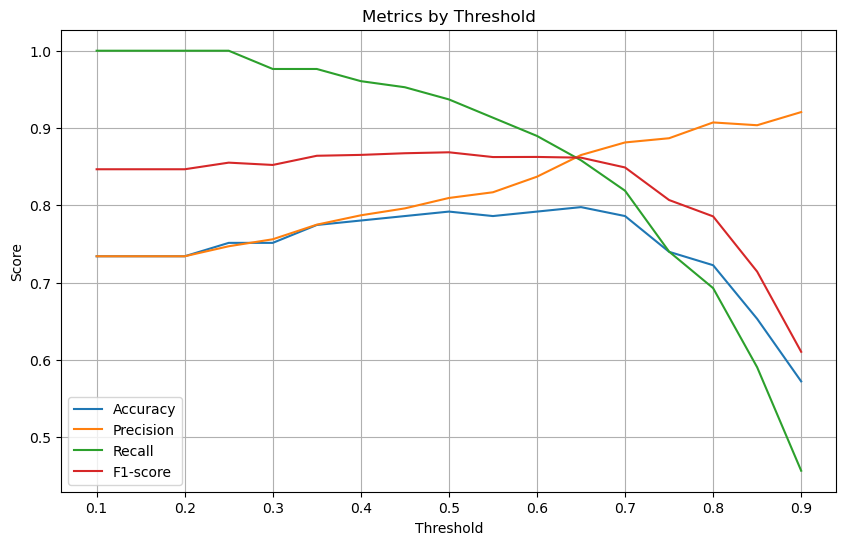

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(metrics_df["threshold"], metrics_df["accuracy"], label="Accuracy")

plt.plot(metrics_df["threshold"], metrics_df["precision"], label="Precision")

plt.plot(metrics_df["threshold"], metrics_df["recall"], label="Recall")

plt.plot(metrics_df["threshold"], metrics_df["f1"], label="F1-score")

plt.xlabel("Threshold")

plt.ylabel("Score")

plt.title("Metrics by Threshold")

plt.legend()

plt.grid()

plt.show()

In [28]:
#metriche nuova soglia
threshold = 0.7

y_pred_04 = (y_prob >= threshold).astype(int)

In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_04))

              precision    recall  f1-score   support

           0       0.58      0.70      0.63        46
           1       0.88      0.82      0.85       127

    accuracy                           0.79       173
   macro avg       0.73      0.76      0.74       173
weighted avg       0.80      0.79      0.79       173



In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_04)

print(cm)

[[ 32  14]
 [ 23 104]]


In [40]:
X_test_sm = X_test.astype(float)

X_test_sm = sm.add_constant(X_test_sm)

y_prob_sm = result.predict(X_test_sm)

threshold = 0.7

y_pred_sm = (y_prob_sm >= threshold).astype(int)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_sm))

from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob_sm)

print("ROC-AUC:", auc)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_sm)

print(cm)

              precision    recall  f1-score   support

           0       0.59      0.70      0.64        46
           1       0.88      0.83      0.85       127

    accuracy                           0.79       173
   macro avg       0.74      0.76      0.75       173
weighted avg       0.81      0.79      0.80       173

ROC-AUC: 0.8045190003423485
[[ 32  14]
 [ 22 105]]


In [31]:
#credit score
credit_score = y_prob * 1000

In [32]:
#dataframe risultati
results = X_test.copy()

results["actual_risk"] = y_test.values

results["probability_good"] = y_prob

results["credit_score"] = credit_score

In [33]:
#funzione segmentazione
def risk_segment(score):
    
    if score >= 700:
        return "Low Risk"
    
    elif score >= 500:
        return "Medium Risk"
    
    else:
        return "High Risk"

In [34]:
#applicare segmentazione
results["risk_segment"] = results["credit_score"].apply(risk_segment)

In [35]:
#analisi segmenti
print(results["risk_segment"].value_counts())

risk_segment
Low Risk       118
Medium Risk     29
High Risk       26
Name: count, dtype: int64


In [36]:
#verifica qualità
pd.crosstab(results["risk_segment"], results["actual_risk"])

actual_risk,0,1
risk_segment,,
High Risk,18,8
Low Risk,14,104
Medium Risk,14,15


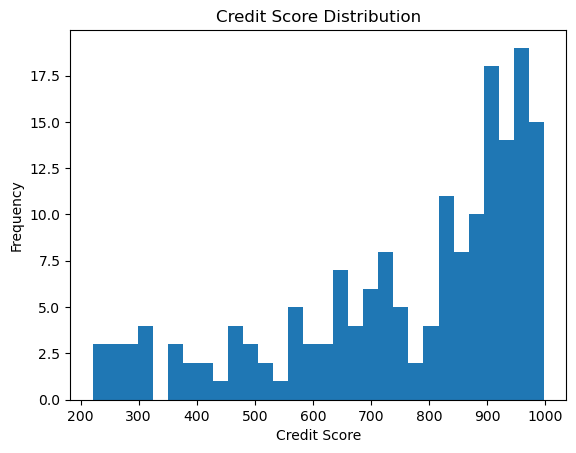

In [37]:
#visualizzazione score
import matplotlib.pyplot as plt

plt.hist(results["credit_score"], bins=30)

plt.title("Credit Score Distribution")

plt.xlabel("Credit Score")

plt.ylabel("Frequency")

plt.show()

In [38]:
pd.crosstab(
    results["risk_segment"],
    results["actual_risk"],
    normalize="index"
)

actual_risk,0,1
risk_segment,,
High Risk,0.692308,0.307692
Low Risk,0.118644,0.881356
Medium Risk,0.482759,0.517241


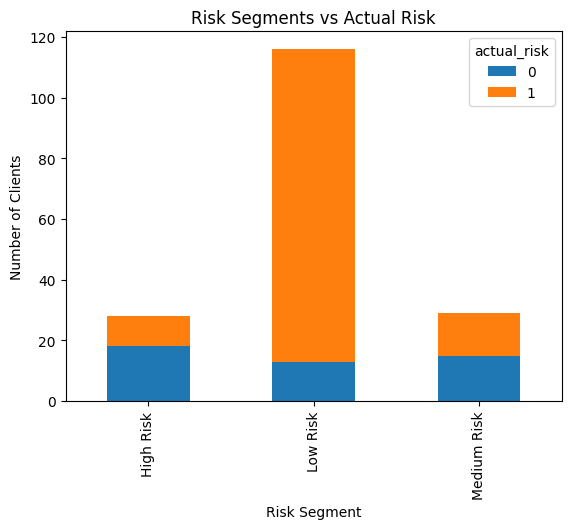

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

ct = pd.crosstab(
    results["risk_segment"],
    results["actual_risk"]
)

ct.plot(kind="bar", stacked=True)

plt.title("Risk Segments vs Actual Risk")

plt.xlabel("Risk Segment")

plt.ylabel("Number of Clients")

plt.show()


In [45]:
results.to_csv(
    "results_clean.csv",
    index=False,
    sep=",",
    decimal="."
)

In [42]:
print(results.head())
print(results.info())
print(results.describe())

     duration  amount  installment_rate  present_residence  age  \
396        12    2578                 3                  4   55   
346        13     882                 4                  4   23   
712        21    2476                 4                  4   46   
527         4    1503                 2                  1   42   
233        18     866                 4                  2   25   

     number_credits  people_liable  \
396               1              1   
346               2              1   
712               1              1   
527               2              2   
233               1              1   

     status_... >= 200 DM / salary for at least 1 year  \
396                                              False   
346                                              False   
712                                              False   
527                                              False   
233                                              False   

     status_0 <= ..

In [43]:
print(results["credit_score"].head(20))

396    394.907787
346    907.950596
712    985.229094
527    979.965700
233    818.500108
48     958.437617
219    889.917461
517    872.283467
644    817.337677
223    950.602476
802    688.041279
246    960.916766
642    903.008662
521    616.240642
626    942.745806
740    285.800566
749    980.413513
868    942.950497
427    979.619088
523    950.272090
Name: credit_score, dtype: float64


In [40]:
df.to_csv("credit_risk_data.csv", index=False)

In [47]:
dashboard_df = results[[
    "actual_risk",
    "probability_good",
    "credit_score",
    "risk_segment",
    "amount",
    "duration",
    "age"
]]

In [49]:
print(dashboard_df.head())
print(len(dashboard_df))

     actual_risk  probability_good  credit_score risk_segment  amount  \
396            1          0.394908    394.907787    High Risk    2578   
346            1          0.907951    907.950596     Low Risk     882   
712            1          0.985229    985.229094     Low Risk    2476   
527            1          0.979966    979.965700     Low Risk    1503   
233            1          0.818500    818.500108     Low Risk     866   

     duration  age  
396        12   55  
346        13   23  
712        21   46  
527         4   42  
233        18   25  
173


In [50]:
dashboard_df.to_csv(
    "dashboard_results.csv",
    index=False
)